In [83]:
# read sensor_list.npy and time_list.npy and plot

import numpy as np
import matplotlib.pyplot as plt
import os
import math

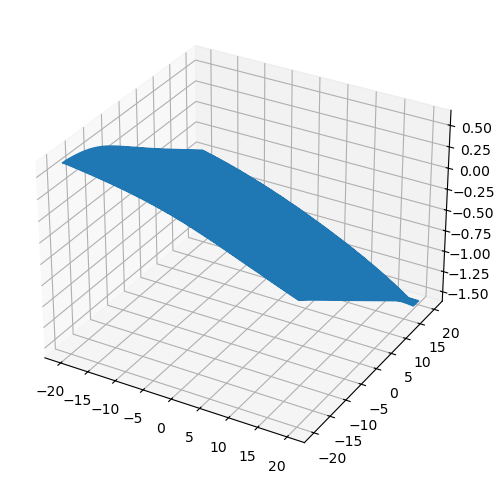

In [84]:
folder_path = "Exp-SingleLeg-Super-20241213_072017"
RobotStateName = os.path.join(folder_path, "StaticState_list.npy")
StaticState = np.load(f"./data/{RobotStateName}")
StaticState.shape

# 创建图形和三维轴
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# 绘制曲面
surf = ax.plot(StaticState[:, 0], StaticState[:, 1], StaticState[:, 3])

(20000, 2)
[[ 1.33977129e-06  1.29379245e-06]
 [ 3.99628051e-06  3.86086253e-06]
 [ 7.94653136e-06  7.68065062e-06]
 ...
 [-2.22266149e-02 -2.22339705e-02]
 [-2.22266149e-02 -2.22339705e-02]
 [-2.22266149e-02 -2.22339705e-02]]


<function matplotlib.pyplot.plot(*args: 'float | ArrayLike | str', scalex: 'bool' = True, scaley: 'bool' = True, data=None, **kwargs) -> 'list[Line2D]'>

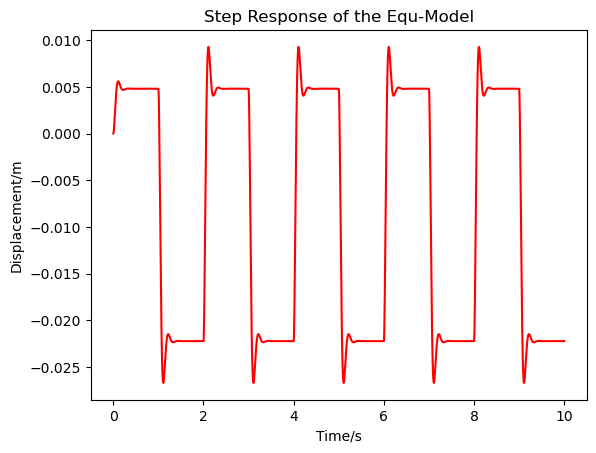

In [85]:
folder_path = "Exp-Exp_MAA-20241213_113617"       # MAA 很好的数据组

# folder_path = "Exp-SingleLeg-20241213_053321"
# folder_path = "Exp-MAA-20241208_003212" # success 740 10 MAA
# folder_path = "Exp-SingleMKC-20241208_000729"     # success of KMC
folder_path_1 = "Exp-Exp_KMC-20241213_113459"     # MKC 对照组
time_list_filename = os.path.join(folder_path, "time_list.npy")
sensor_list_filename = os.path.join(folder_path, "sensor_list.npy")
sensor_list_filename_1 = os.path.join(folder_path_1, "sensor_list.npy")
time_list_filename_1 = os.path.join(folder_path_1, "time_list.npy")
time_list = np.load(f'./data/{time_list_filename}')
time_list_1 = np.load(f'./data/{time_list_filename_1}')
sensor_list = np.load(f'./data/{sensor_list_filename}')
sensor_list_1 = np.load(f'./data/{sensor_list_filename_1}')
print(sensor_list.shape)
print(sensor_list)
plt.plot(time_list, sensor_list[:,0], "-r")
plt.xlabel("Time/s")
plt.ylabel("Displacement/m")
plt.title("Step Response of the Equ-Model")
# plt.plot(time_list_1, sensor_list_1[:,0], "-b")
plt.plot

In [86]:
sensor_list.shape
indices_in_range = np.where((time_list>=0.8) & (time_list<=1.8))
sensor_list[indices_in_range][:, 0].shape, sensor_list[indices_in_range][:, 1].shape

((2000,), (2000,))

(array([1600, 1601, 1602, ..., 3597, 3598, 3599]),)
(2000, 2)
0.004800414055821833 -0.022226477890508356
[[ 0.00480042  0.00480042  0.00480042 ... -0.02222666 -0.02222666
  -0.02222666]]
0.34122222223333326
overshot: 0.1656662558723078
tp: 0.10849999999993343
zeta: 0.49667705036429377
omega_n: 33.360512842126234
k: 379.75433804374074
c: 11.307695740482426
MSE = 3.2044627952596637e-07


((20000,), (20000,))

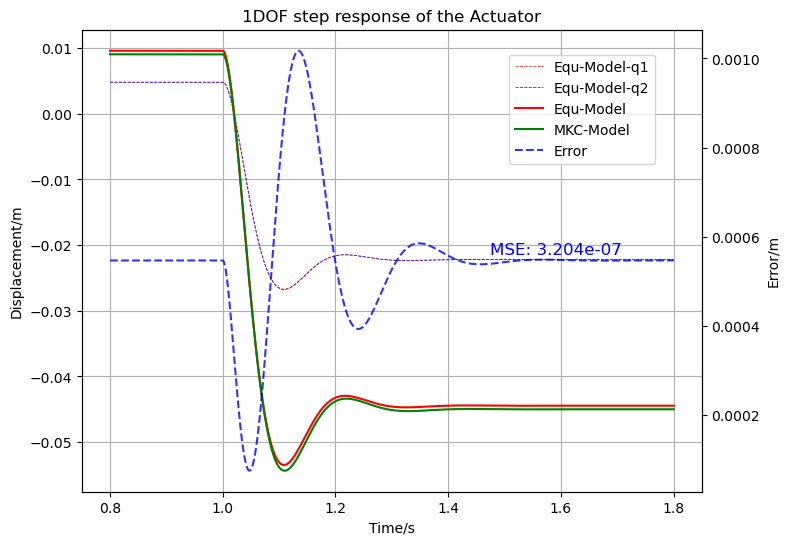

In [ ]:
# NOTE： 在1s施加脉冲
indices_in_range = np.where((time_list>=0.8) & (time_list<=1.8))

# 绘制双坐标图
fig, ax1 = plt.subplots(figsize=(8, 6))  # 控制图形大小
ax2 = ax1.twinx()  # 创建第二个坐标轴
ax1.plot(time_list[indices_in_range], sensor_list[indices_in_range][:, 0], "--r", label="Equ-Model-q1", linewidth=0.6, alpha=0.8)   # 1DOF MAA
ax1.plot(time_list[indices_in_range], sensor_list[indices_in_range][:, 1], "--b", label="Equ-Model-q2", linewidth=0.6, alpha=0.8)   # 1DOF MAA
ax1.plot(time_list[indices_in_range], sensor_list[indices_in_range][:, 0] + sensor_list[indices_in_range][:, 1], "-r", label="Equ-Model")   # 1DOF MAA
ax1.plot(time_list_1[indices_in_range], sensor_list_1[indices_in_range][:, 0], "-g", label="MKC-Model")   # 1DOF MAA

ax1.set_xlabel("Time/s")
ax1.set_ylabel("Displacement/m")
ax2.set_ylabel("Error/m")
plt.title("1DOF step response of the Actuator")

# 计算平方平均误差
error = sensor_list[indices_in_range][:, 0] + sensor_list[indices_in_range][:, 1] - sensor_list_1[indices_in_range][:, 0]
ax2.plot(time_list[indices_in_range], error, "--b", label="Error", alpha=0.8)
# 计算MSE
MSE = np.sum(np.square(error))/len(error)
print(f"MSE = {MSE}")
# 标注右下角数据
right_bottom_text = f"MSE: {MSE.round(10)}"
fig.text(
    0.8, 0.5,  # 图像坐标 (右下角)
    right_bottom_text, 
    fontsize=12, 
    color="blue", 
    ha="right", 
    va="bottom"
)

ax1.grid()
# 添加图例
fig.legend(loc="upper right", bbox_to_anchor=(0.85, 0.85))

# 稳态
indices_start = np.where((time_list>=0.8) & (time_list<=1.0))
indices_end = np.where((time_list>=1.6) & (time_list<=1.8))
# print(sensor_list[indices_start, 0])
len_start = np.average(sensor_list[indices_start, 0])
len_end = np.average(sensor_list[indices_end, 0])
print(len_start, len_end)

min_len = np.min(sensor_list[indices_in_range, 0])
print(sensor_list[indices_in_range, 0])

overshot = (min_len-len_end)/(len_end-len_start)
# print(np.argmax(sensor_list[indices_in_range, 0]))
tp = time_list[indices_in_range[0][0] + np.argmin(sensor_list[indices_in_range, 0])] - 1  # NOTE: 我们把1s作为开始    # KMC
# tp = time_list[indices_in_range[0][0] + np.argmin(sensor_list[indices_in_range])] - 1  # NOTE: 我们把1s作为开始    # KMC
# calculat zeta and omega_n
zeta = -math.log(overshot)/(math.sqrt(math.pi**2+math.log(overshot)**2))
omega_n = math.pi/tp/math.sqrt(1-zeta**2)
# m
m_floatingMass = 0.1236666667
m_end = 0.3 # 0.03091666667
m_equal = 0 + 1/3*(m_floatingMass+3*m_end) # 1
print(m_equal)
# m_equal = 0 + 1
k = (m_equal) * omega_n**2
c = (m_equal) * 2*zeta*omega_n

print(f"overshot: {overshot}")
print(f"tp: {tp}")
print(f"zeta: {zeta}")
print(f"omega_n: {omega_n}")
print(f"k: {k}")
print(f"c: {c}")